In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 


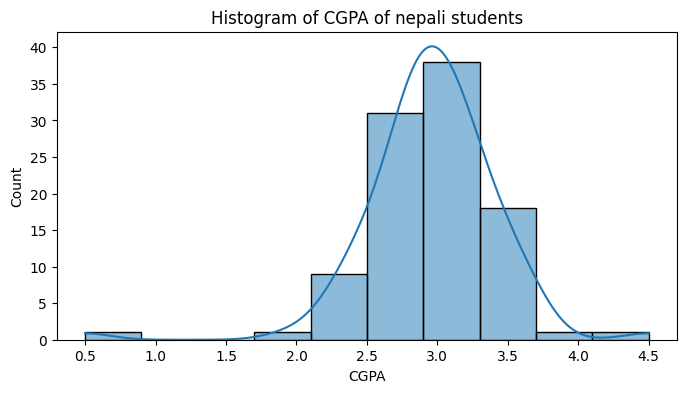

In [2]:
df = pd.read_csv(r'nepali_students_dataset.csv')

# checking the dataset if it has normal distribution
plt.figure(figsize = (8,4))
sns.histplot(df['CGPA'], bins = 10, kde = True)
plt.title('Histogram of CGPA of nepali students')
plt.show()


In [3]:
# As it has got the bell type curve in it, we have to use z-score method to detect and remove outliers
try:
    df['CGPA'] = df['CGPA'].astype(float)
    df['IQ'] = df['IQ'].astype(float)

    mean_c = df['CGPA'].mean()
    std_c = df['CGPA'].std()

    mean_i = df['IQ'].mean()
    std_i = df['IQ'].std()

    lower_i = mean_i - 3 * std_i
    upper_i = mean_i + 3 * std_i

    lower_c = mean_c - 3 * std_c
    upper_c = mean_c + 3 * std_c

    df = df[(df['CGPA'] >= lower_c) & (df['CGPA'] <= upper_c)]
    df = df[(df['IQ'] >= lower_i) & (df['IQ'] <= upper_i)]
    
    outliers_c = df[(df['CGPA'] <= lower_c) & (df['CGPA'] >= upper_c)]
    outliers_i = df[(df['IQ'] <= lower_i) & (df['IQ'] >= upper_i)]

    # print(f'The detected outlier from the dataset are: {outliers}')
    # outliers.dropna()
    print(outliers_c)
    print(outliers_i)

except Exception as e:
    raise KeyError from e




Empty DataFrame
Columns: [Name, Roll_no, Class, CGPA, IQ, Age]
Index: []
Empty DataFrame
Columns: [Name, Roll_no, Class, CGPA, IQ, Age]
Index: []


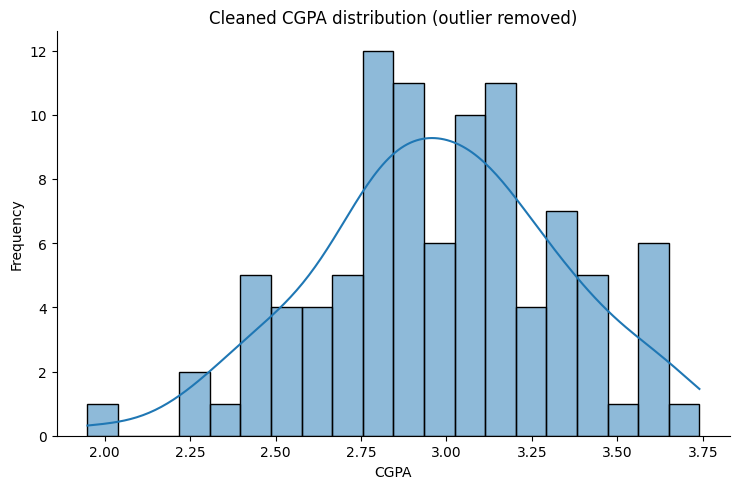

In [4]:
# Visualiztaion of cleaned dataset

plt.Figure(figsize = (8,5))
sns.displot(df['CGPA'], bins = 20, kde = True, height = 5, aspect = 1.5)
plt.title('Cleaned CGPA distribution (outlier removed)')
plt.xlabel('CGPA')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
